In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
!ln -s /content/gdrive/My\ Drive/ /mydrive
%cd /mydrive/yolov9-main/yolov9-otherbranches/yolov9-add_panoptic_eval
!ls

Mounted at /content/gdrive
/content/gdrive/.shortcut-targets-by-id/1FsxtjdRhKCSS4b319zT5rcL3Dd5sOLs5/yolov9-main/yolov9-otherbranches/yolov9-add_panoptic_eval
benchmarks.py	hubconf.py	requirements.txt  train_triple.py
classify	LICENSE.md	runs		  utils
data		models		scripts		  val_dual.py
detect_dual.py	panoptic	segment		  val.py
detect.py	panoptic-tests	tools		  val_triple.py
export.py	__pycache__	train_dual.py	  YOLOv9-PAN-seg.ipynb
figure		README.md	train.py


In [ ]:
%pip install -qr requirements.txt # install dependencies
import torch
import os
print(f"Setup complete. Using torch {torch.__version__} ({torch.cuda.get_device_properties(0).name if torch.cuda.is_available() else 'CPU'})")

In [ ]:
predict.py [-h] [--weights WEIGHTS [WEIGHTS ...]] [--source SOURCE]
                  [--data DATA] [--imgsz IMGSZ [IMGSZ ...]]
                  [--conf-thres CONF_THRES] [--iou-thres IOU_THRES]
                  [--max-det MAX_DET] [--device DEVICE] [--view-img]
                  [--save-txt] [--save-conf] [--save-crop] [--nosave]
                  [--classes CLASSES [CLASSES ...]] [--agnostic-nms]
                  [--augment] [--visualize] [--update] [--project PROJECT]
                  [--name NAME] [--exist-ok] [--line-thickness LINE_THICKNESS]
                  [--hide-labels] [--hide-conf] [--half] [--dnn]
                  [--vid-stride VID_STRIDE] [--retina-masks] [--export-mask]
                  [--color-map COLOR_MAP]

In [ ]:
!python panoptic/predict.py --weights models/gelan-c-pan.pt --data coco.yaml --imgsz 640 --conf-thres 0.25 --source panoptic-tests/beach1.png --export-mask --retina-masks

panoptic/predict: weights=['models/gelan-c-pan.pt'], source=panoptic-tests/beach1.png, data=coco.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/predict-seg, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1, retina_masks=True, export_mask=True, color_map=data/color_map.pickle
YOLO 🚀 2025-8-17 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
gelan-c-pan summary: 419 layers, 27582573 parameters, 0 gradients, 146.7 GFLOPs
{'nc': 80, 'depth_multiple': 1.0, 'width_multiple': 1.0, 'anchors': 3, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 1, 'RepNCSPELAN4', [256, 128, 64, 1]], [-1, 1, 'ADown', [256]], [-1, 1, 'RepNCSPELAN4', [512, 256, 128, 1]], [-1, 1, 'ADown', 

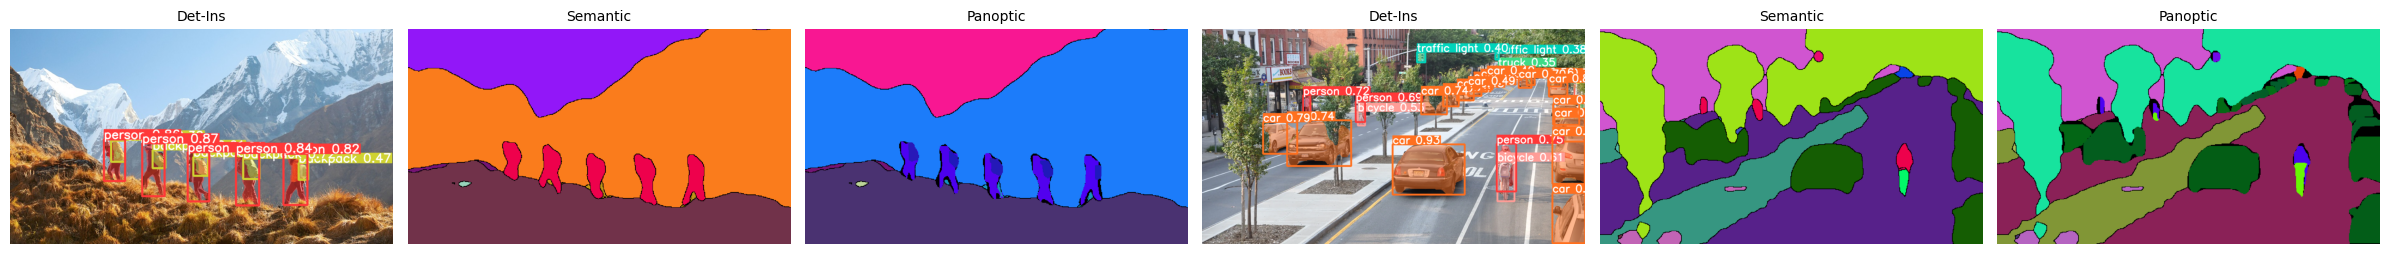

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
import math

# --- Configuration ---
exp_dirs = [
    "runs/predict-seg/exp2",
    "runs/predict-seg/exp3",
    #"runs/predict-seg/exp5",
]

cols = 6       # total grid columns
per_exp = 3    # images per experiment (Det-Ins, Semantic, Panoptic)

col_titles = ["Det-Ins", "Semantic", "Panoptic"]

if cols % per_exp != 0:
    cols = (cols // per_exp) * per_exp  # snap down to nearest multiple

def classify_type(fname):
    if "_panoptic_mask" in fname:
        return "panoptic"
    elif "_mask" in fname:
        return "semantic"
    else:
        return "det"

# --- Collect & group ---
exp_samples = {}  # {exp_name: [ {"det":path, "semantic":path, "panoptic":path}, ... ] }
for d in exp_dirs:
    exp_name = os.path.basename(d.rstrip("/"))
    paths = []
    for pat in ("*.png", "*.jpg", "*.jpeg"):
        paths.extend(glob(os.path.join(d, pat)))

    grouped = {}
    for p in paths:
        base = os.path.basename(p)
        stem, _ = os.path.splitext(base)
        # remove suffixes in the correct order
        stem_key = stem.replace("_panoptic_mask", "").replace("_mask", "")
        grouped.setdefault(stem_key, {})
        grouped[stem_key][classify_type(base)] = p

    # keep a stable order by stem_key
    exp_samples[exp_name] = [grouped[k] for k in sorted(grouped.keys())]

# --- Plot ---
total_samples = sum(len(v) for v in exp_samples.values())
total_slots = total_samples * per_exp
rows = math.ceil(total_slots / cols)

plt.figure(figsize=(4 * cols, 4 * rows))
idx = 1

for exp, samples in exp_samples.items():
    for sample in samples:
        ordered_paths = [sample.get("det"), sample.get("semantic"), sample.get("panoptic")]
        for i, p in enumerate(ordered_paths):
            plt.subplot(rows, cols, idx)
            if p and os.path.exists(p):
                img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
                plt.imshow(img)
                plt.title(col_titles[i], fontsize=10)
            else:
                # keep grid position to preserve titles/columns even if missing
                plt.title(col_titles[i] + " (missing)", fontsize=10)
            plt.axis("off")
            idx += 1

plt.tight_layout()
plt.show()

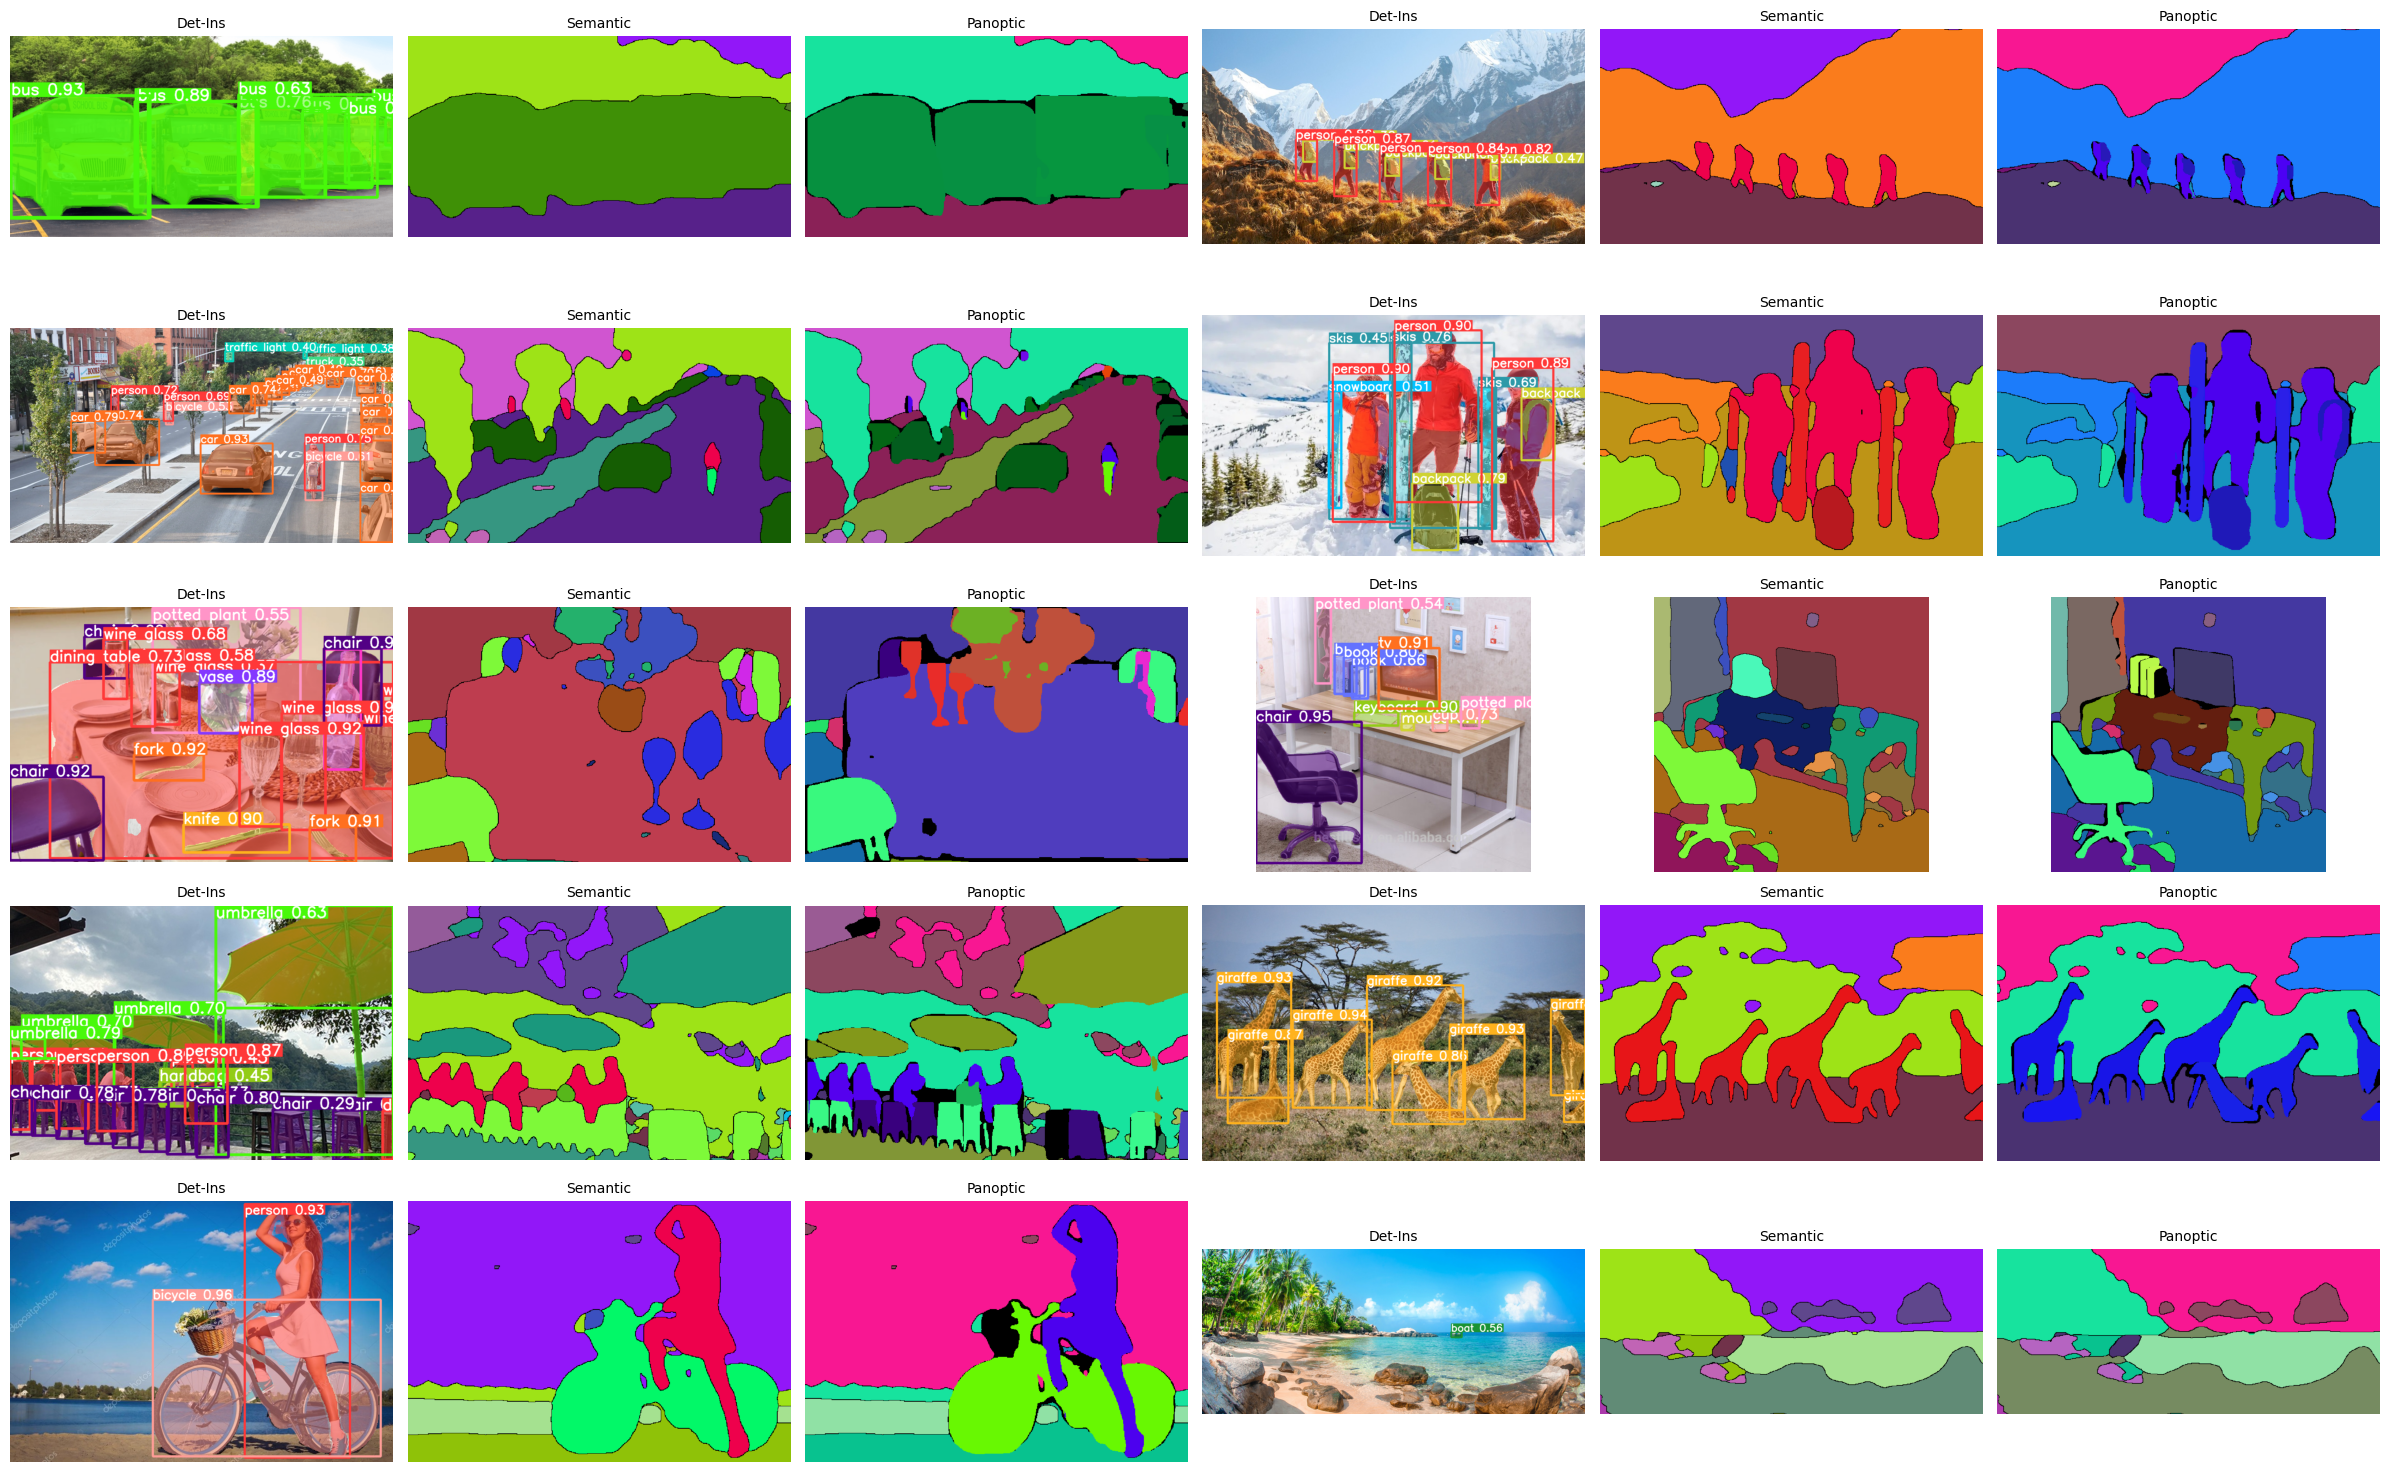

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
import math

# --- Configuration ---
exp_dirs = [
    "runs/predict-seg/exp",
    "runs/predict-seg/exp2",
    "runs/predict-seg/exp3",
    "runs/predict-seg/exp4",
    "runs/predict-seg/exp5",
    "runs/predict-seg/exp6",
    "runs/predict-seg/exp7",
    "runs/predict-seg/exp8",
    "runs/predict-seg/exp9",
    "runs/predict-seg/exp10",
]

cols = 6       # total grid columns
per_exp = 3    # images per experiment (Det-Ins, Semantic, Panoptic)

col_titles = ["Det-Ins", "Semantic", "Panoptic"]

if cols % per_exp != 0:
    cols = (cols // per_exp) * per_exp  # snap down to nearest multiple

def classify_type(fname):
    if "_panoptic_mask" in fname:
        return "panoptic"
    elif "_mask" in fname:
        return "semantic"
    else:
        return "det"

# --- Collect & group ---
exp_samples = {}  # {exp_name: [ {"det":path, "semantic":path, "panoptic":path}, ... ] }
for d in exp_dirs:
    exp_name = os.path.basename(d.rstrip("/"))
    paths = []
    for pat in ("*.png", "*.jpg", "*.jpeg"):
        paths.extend(glob(os.path.join(d, pat)))

    grouped = {}
    for p in paths:
        base = os.path.basename(p)
        stem, _ = os.path.splitext(base)
        # remove suffixes in the correct order
        stem_key = stem.replace("_panoptic_mask", "").replace("_mask", "")
        grouped.setdefault(stem_key, {})
        grouped[stem_key][classify_type(base)] = p

    # keep a stable order by stem_key
    exp_samples[exp_name] = [grouped[k] for k in sorted(grouped.keys())]

# --- Plot ---
total_samples = sum(len(v) for v in exp_samples.values())
total_slots = total_samples * per_exp
rows = math.ceil(total_slots / cols)

plt.figure(figsize=(4 * cols, 3 * rows))
idx = 1

for exp, samples in exp_samples.items():
    for sample in samples:
        ordered_paths = [sample.get("det"), sample.get("semantic"), sample.get("panoptic")]
        for i, p in enumerate(ordered_paths):
            plt.subplot(rows, cols, idx)
            if p and os.path.exists(p):
                img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
                plt.imshow(img)
                plt.title(col_titles[i], fontsize=10)
            else:
                # keep grid position to preserve titles/columns even if missing
                plt.title(col_titles[i] + " (missing)", fontsize=10)
            plt.axis("off")
            idx += 1

plt.tight_layout()
plt.show()

In [ ]:
!python panoptic/predict.py --weights models/gelan-c-pan.pt --data coco.yaml --imgsz 640 --conf-thres 0.25 --source panoptic-tests/street2.png --export-mask --retina-masks

panoptic/predict: weights=['models/gelan-c-pan.pt'], source=panoptic-tests/street2.png, data=coco.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/predict-seg, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1, retina_masks=True, export_mask=True, color_map=data/color_map.pickle
YOLO 🚀 2025-8-17 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
gelan-c-pan summary: 419 layers, 27582573 parameters, 0 gradients, 146.7 GFLOPs
{'nc': 80, 'depth_multiple': 1.0, 'width_multiple': 1.0, 'anchors': 3, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 1, 'RepNCSPELAN4', [256, 128, 64, 1]], [-1, 1, 'ADown', [256]], [-1, 1, 'RepNCSPELAN4', [512, 256, 128, 1]], [-1, 1, 'ADown',

In [ ]:
street1.png: 3 persons, 2 bicycles, 18 cars, 1 truck, 2 traffic lights, 1 building-other, 1 bush, 1 dirt, 1 grass, 1 pavement, 1 road, 1 tree

In [ ]:
room2.png: 384x640 1 cup, 3 chairs, 1 couch, 3 potted plants, 1 dining table, 1 book, 2 vases, 1 cabinet, 1 carpet, 1 ceiling-other, 1 curtain, 1 door-stuff, 1 floor-other, 1 floor-wood, 1 furniture-other, 1 mirror-stuff, 1 rug, 1 table, 1 wall-brick, 1 wall-concrete, 1 wall-other, 1 wall-stone, 1 wall-wood, 1 window-other

In [ ]:
table.png: 448x640 1 bottle, 7 wine glasss, 2 forks, 1 knife, 3 chairs, 1 potted plant, 1 dining table, 1 vase, 1 floor-other, 1 floor-tile, 1 floor-wood, 1 flower, 1 metal, 1 sky-other, 1 table, 1 wall-concrete

In [ ]:
snowboard2.png: 448x640 1 person, 1 snowboard, 1 clouds, 1 mountain, 1 snow, 1 tree

In [ ]:
motorcycles1.png: 480x640 8 motorcycles, 1 building-other, 1 clouds, 1 door-stuff, 1 fence, 1 grass, 1 pavement, 1 road, 1 roof, 1 sky-other, 1 tree, 1 wall-brick, 1 window-other

In [ ]:
beach1.png: 288x640 1 boat, 1 clouds, 1 dirt, 1 grass, 1 rock, 1 sand, 1 sea, 1 sky-other, 1 tree, 1 wood

In [ ]:
birds.png: 384x640 6 birds, 1 clouds, 1 grass, 1 mountain, 1 sky-other, 1 tree

In [ ]:
ships1.png: 384x640 2 boats, 1 mountain, 1 rock, 1 sea, 1 sky-other

In [ ]:
horses.png: 448x640 5 persons, 5 horses, 1 clouds, 1 dirt, 1 grass, 1 hill, 1 mountain, 1 rock, 1 sky-other, 1 tree

In [ ]:
hiking.png: 384x640 5 persons, 5 backpacks, 1 grass, 1 hill, 1 mountain, 1 sky-other, 1 snow, 1 straw

In [ ]:
beach2.png: 448x640 1 person, 1 bicycle, 1 clouds, 1 sand, 1 sea, 1 sky-other, 1 snow, 1 tree

In [ ]:
bridge.png: 384x640 3 boats, 1 bridge, 1 building-other, 1 dirt, 1 grass, 1 hill, 1 metal, 1 mountain, 1 pavement, 1 platform, 1 railroad, 1 river, 1 road, 1 sand, 1 sea, 1 sky-other

In [ ]:
school-buses1.png: 352x640 4 buss, 1 building-other, 1 metal, 1 road, 1 sky-other, 1 tree

In [ ]:
giraffes.png: 448x640 8 giraffes, 1 grass, 1 mountain, 1 sky-other, 1 tree

In [ ]:
coffeeshop.png: 448x640 6 persons, 5 umbrellas, 2 handbags, 10 chairs, 1 dining table, 1 bush, 1 ceiling-other, 1 clouds, 1 fence, 1 floor-other, 1 furniture-other, 1 grass, 1 metal, 1 pavement, 1 sky-other, 1 tree, 1 wall-other, 1 wood

In [ ]:
room1.png: 640x640 1 cup, 1 chair, 2 potted plants, 1 tv, 1 mouse, 1 keyboard, 3 books, 1 cabinet, 1 carpet, 1 curtain, 1 desk-stuff, 1 floor-other, 1 floor-tile, 1 floor-wood, 1 furniture-other, 1 paper, 1 shelf, 1 table, 1 wall-concrete, 1 wall-tile, 1 window-other

In [ ]:
snowboard1.png: 416x640 3 persons, 2 backpacks, 5 skiss, 1 snowboard, 1 clouds, 1 mountain, 1 snow, 1 tree

In [ ]:
street2.png: 448x640 1 clouds, 1 grass, 1 road, 1 sky-other, 1 tree, (no detections)

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from glob import glob
import math

# --- Configuration ---
exp_dirs = [
    "runs/predict-seg/exp11",
    "runs/predict-seg/exp12",
    "runs/predict-seg/exp13",
    "runs/predict-seg/exp14",
    "runs/predict-seg/exp15",
    "runs/predict-seg/exp16",
    "runs/predict-seg/exp17",
    "runs/predict-seg/exp18",
    "runs/predict-seg/exp19",
    "runs/predict-seg/exp20",
    "runs/predict-seg/exp21",
    "runs/predict-seg/exp22",
    "runs/predict-seg/exp23",
    "runs/predict-seg/exp24",
    "runs/predict-seg/exp25",
    "runs/predict-seg/exp26",
    "runs/predict-seg/exp27",
    "runs/predict-seg/exp28",
]

cols = 5       # total grid columns
per_exp = 5    # images per experiment

col_titles = ["Det-Ins", "Semantic", "Sem-Overlay", "Panoptic", "Pan-Overlay"]

if cols % per_exp != 0:
    cols = (cols // per_exp) * per_exp  # snap down to nearest multiple

def classify_type(fname):
    if "_panoptic_overlay" in fname:
        return "panoverlay"
    elif "_mask_overlay" in fname:
        return "semoverlay"
    elif "_panoptic_mask" in fname:
        return "panoptic"
    elif "_mask" in fname:
        return "semantic"
    else:
        return "det"

# --- Collect & group ---
exp_samples = {}  # {exp_name: [ {"det":path, "semantic":path, "panoptic":path}, ... ] }
for d in exp_dirs:
    exp_name = os.path.basename(d.rstrip("/"))
    paths = []
    for pat in ("*.png", "*.jpg", "*.jpeg"):
        paths.extend(glob(os.path.join(d, pat)))

    grouped = {}
    for p in paths:
        base = os.path.basename(p)
        stem, _ = os.path.splitext(base)
        # remove suffixes in the correct order
        stem_key = stem.replace("_panoptic_mask", "").replace("_panoptic_overlay", "").replace("_mask_overlay", "").replace("_mask", "")
        grouped.setdefault(stem_key, {})
        grouped[stem_key][classify_type(base)] = p

    # keep a stable order by stem_key
    exp_samples[exp_name] = [grouped[k] for k in sorted(grouped.keys())]

# --- Plot ---
total_samples = sum(len(v) for v in exp_samples.values())
total_slots = total_samples * per_exp
rows = math.ceil(total_slots / cols)

plt.figure(figsize=(4 * cols, 3 * rows))
idx = 1

for exp, samples in exp_samples.items():
    for sample in samples:
        ordered_paths = [sample.get("det"), sample.get("semantic"), sample.get("semoverlay"), sample.get("panoptic"), sample.get("panoverlay")]
        for i, p in enumerate(ordered_paths):
            plt.subplot(rows, cols, idx)
            if p and os.path.exists(p):
                img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
                plt.imshow(img)
                plt.title(col_titles[i], fontsize=10)
            else:
                # keep grid position to preserve titles/columns even if missing
                plt.title(col_titles[i] + " (missing)", fontsize=10)
            plt.axis("off")
            idx += 1

plt.tight_layout()
plt.show()

In [ ]:
!pip install keytotext --upgrade

In [ ]:
%pip install datasets==1.18.4

In [ ]:
!pip install -q transformers datasets torchvision pycocotools

In [ ]:
import transformers
from torch.optim import AdamW
from transformers.optimization import get_linear_schedule_with_warmup

# patch the function
_old_batch_encode_plus = transformers.PreTrainedTokenizerFast._batch_encode_plus
def _patched_batch_encode_plus(self, *args, **kwargs):
    kwargs.pop('pad_to_max_length', None)  # remove the deprecated argument
    return _old_batch_encode_plus(self, *args, **kwargs)

transformers.PreTrainedTokenizerFast._batch_encode_plus = _patched_batch_encode_plus

# expose the symbols where keytotext expects them
transformers.AdamW = AdamW
transformers.get_linear_schedule_with_warmup = get_linear_schedule_with_warmup
from keytotext import pipeline
nlp = pipeline("mrm8488/t5-base-finetuned-common_gen")

In [ ]:
print(nlp(['','','','','']))

In [ ]:
#street1.png: 3 persons, 2 bicycles, 18 cars, 1 truck, 2 traffic lights, 1 building-other, 1 bush, 1 dirt, 1 grass, 1 pavement, 1 road, 1 tree
print(nlp(['3persons','2bicycles','18cars','road','tree']))

2bicycles and 18cars on a road


In [ ]:
#room2.png: 384x640 1 cup, 3 chairs, 1 couch, 3 potted plants, 1 dining table, 1 book, 2 vases, 1 cabinet, 1 carpet, 1 ceiling-other, 1 curtain, 1 door-stuff, 1 floor-other, 1 floor-wood, 1 furniture-other, 1 mirror-stuff, 1 rug, 1 table, 1 wall-brick, 1 wall-concrete, 1 wall-other, 1 wall-stone, 1 wall-wood, 1 window-other
print(nlp(['1diningtable','3chairs','3pottedplants','1cup','1book']))

A dining table with 3 chairs, 3 potted plants, and a book.


In [ ]:
#table.png: 448x640 1 bottle, 7 wine glasss, 2 forks, 1 knife, 3 chairs, 1 potted plant, 1 dining table, 1 vase, 1 floor-other, 1 floor-tile, 1 floor-wood, 1 flower, 1 metal, 1 sky-other, 1 table, 1 wall-concrete
print(nlp(['1diningtable','3chairs','1pottedplant','7wineglasss','1bottle']))

1dining table with 3 chairs, 1 potted plant, and 1 bottle of wine.


In [ ]:
#snowboard2.png: 448x640 1 person, 1 snowboard, 1 clouds, 1 mountain, 1 snow, 1 tree
print(nlp(['1person','1snowboard','mountain','snow','tree']))

1person on a snowboard and 1snowboard in the snow on the mountain


In [ ]:
#motorcycles1.png: 480x640 8 motorcycles, 1 building-other, 1 clouds, 1 door-stuff, 1 fence, 1 grass, 1 pavement, 1 road, 1 roof, 1 sky-other, 1 tree, 1 wall-brick, 1 window-other
print(nlp(['8motorcycles','building','tree','road','pavement']))

8motorcycles on the pavement next to a building


In [ ]:
#beach1.png: 288x640 1 boat, 1 clouds, 1 dirt, 1 grass, 1 rock, 1 sand, 1 sea, 1 sky-other, 1 tree, 1 wood
print(nlp(['1boat','sea','tree','rock','sand']))

a boat in the sea with rocks and sand


In [ ]:
#birds.png: 384x640 6 birds, 1 clouds, 1 grass, 1 mountain, 1 sky-other, 1 tree
print(nlp(['6birds','mountain','tree','sky','grass']))

a group of 6 birds grazing on grass near a mountain under a blue sky


In [ ]:
#ships1.png: 384x640 2 boats, 1 mountain, 1 rock, 1 sea, 1 sky-other
print(nlp(['2boats','sea','mountain','rock','sky']))

2boats in the sea against a blue sky


In [ ]:
#horses.png: 448x640 5 persons, 5 horses, 1 clouds, 1 dirt, 1 grass, 1 hill, 1 mountain, 1 rock, 1 sky-other, 1 tree
print(nlp(['5persons','5horses','dirt','mountain','rock']))

A group of 5 people and 5 horses graze on dirt next to rocks.


In [ ]:
#hiking.png: 384x640 5 persons, 5 backpacks, 1 grass, 1 hill, 1 mountain, 1 sky-other, 1 snow, 1 straw
print(nlp(['5persons','5backpacks','mountain','snow','grass']))

A group of 5 people with backpacks and 5backpacks in the snow.


In [ ]:
#beach2.png: 448x640 1 person, 1 bicycle, 1 clouds, 1 sand, 1 sea, 1 sky-other, 1 snow, 1 tree
print(nlp(['1person','1bicycle','sea','sand','tree']))

1 person on a bicycle in the sand near the sea


In [ ]:
#bridge.png: 384x640 3 boats, 1 bridge, 1 building-other, 1 dirt, 1 grass, 1 hill, 1 metal, 1 mountain, 1 pavement, 1 platform, 1 railroad, 1 river, 1 road, 1 sand, 1 sea, 1 sky-other
print(nlp(['3boats','bridge','river','mountain','sky']))

3boats on a river under a cloudy sky


In [ ]:
#school-buses1.png: 352x640 4 buss, 1 building-other, 1 metal, 1 road, 1 sky-other, 1 tree
print(nlp(['4buses','building','road','tree','sky']))

4buses on a road with trees against a blue sky


In [ ]:
#giraffes.png: 448x640 8 giraffes, 1 grass, 1 mountain, 1 sky-other, 1 tree
print(nlp(['8giraffes','mountain','tree','grass','sky']))

A group of giraffes grazing on grass and trees under a blue sky.


In [ ]:
#coffeeshop.png: 448x640 6 persons, 5 umbrellas, 2 handbags, 10 chairs, 1 dining table, 1 bush, 1 ceiling-other, 1 clouds, 1 fence, 1 floor-other, 1 furniture-other, 1 grass, 1 metal, 1 pavement, 1 sky-other, 1 tree, 1 wall-other, 1 wood
print(nlp(['6persons','5umbrellas','10chairs','diningtable','tree']))

A dining table with chairs, a table and chairs, and a tree.


In [ ]:
#room1.png: 640x640 1 cup, 1 chair, 2 potted plants, 1 tv, 1 mouse, 1 keyboard, 3 books, 1 cabinet, 1 carpet, 1 curtain, 1 desk-stuff, 1 floor-other, 1 floor-tile, 1 floor-wood, 1 furniture-other, 1 paper, 1 shelf, 1 table, 1 wall-concrete, 1 wall-tile, 1 window-other
print(nlp(['1chair','table','2pottedplants','1tv','1keyboard']))

1chair, 1table, 2potted plants, and 1keyboard.


In [ ]:
#snowboard1.png: 416x640 3 persons, 2 backpacks, 5 skiss, 1 snowboard, 1 clouds, 1 mountain, 1 snow, 1 tree
print(nlp(['3persons','2backpacks','1snowboard','mountain','snow']))

A group of 3 people with 2 backpacks and 1snowboard in the snow.


In [ ]:
#street2.png: 448x640 1 clouds, 1 grass, 1 road, 1 sky-other, 1 tree, (no detections)
print(nlp(['road','tree','grass','sky','cloud']))

a road with trees and clouds in the sky
